# 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces

The previous notebook argued that transparent models deserve to be taken seriously as deployment candidates. This notebook asks a different question: **once we have a transparent model, how do we read it correctly?** That turns out to be more subtle than many applied workflows admit. A coefficient can live on the raw-unit scale, a standardized scale, the log-odds scale, or the probability scale. Those are not interchangeable. Likewise, a positive interaction coefficient in a logistic model still needs to be translated into probability-scale behavior before we claim a uniformly positive interaction effect.

We will work inside a realistic account-triage setting. An operations team wants to forecast next-month specialist support hours and decide which accounts need specialist review before service failures occur. The notebook uses that workflow to develop four habits that are central to interpretable modeling: read coefficients on the scale the model actually uses, convert effects into meaningful business shifts before comparing them, distinguish odds changes from probability changes, and rely on response surfaces whenever interaction structure matters.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain the difference between a raw-unit coefficient, a standardized effect, an odds ratio, and a probability change.
2. Interpret linear-model coefficients as conditional changes in the predicted outcome for meaningful feature shifts.
3. Interpret logistic-model coefficients on the log-odds scale and translate them into odds multipliers for business-relevant changes.
4. Show mathematically why the same logistic coefficient can imply very different probability changes at different baseline risk levels.
5. Read categorical coefficients relative to explicit reference levels rather than as stand-alone quantities.
6. Use response surfaces to interpret interactions and nonlinear structure in transparent models.
7. Identify the most common ways practitioners misread interpretable models in decision workflows.

In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 160)
np.random.seed(2026)

CATEGORICAL_LEVELS = {
    'segment': ['growth', 'mid-market', 'enterprise'],
    'region': ['North', 'South', 'West', 'International'],
    'support_motion': ['reactive', 'pooled', 'dedicated'],
}

MEANINGFUL_SHIFTS = {
    'open_tickets_30d': ('+3 tickets', 3.0),
    'integration_complexity': ('+2 complexity points', 2.0),
    'training_completion': ('-10 percentage points', -0.10),
    'product_adoption': ('-10 percentage points', -0.10),
    'payment_delay_days': ('+5 days', 5.0),
    'recent_incidents_90d': ('+1 incident', 1.0),
    'usage_volatility': ('+0.5 volatility units', 0.5),
    'executive_sponsor': ('0 -> 1', 1.0),
}

In [2]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))


def make_one_hot_encoder(categories=None, drop='first'):
    """Construct the one hot encoder helper used in the 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces workflow.
    
    Parameters
    ----------
    categories : object
        The categories setting that controls the one hot encoder calculation in this notebook.
    drop : object
        The drop setting that controls the one hot encoder calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the one hot encoder calculation and reused by later cells.
    """
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False, categories=categories, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False, categories=categories, drop=drop)


def clean_feature_name(name):
    """Clean feature name so it can be interpreted in the 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces workflow.
    
    Parameters
    ----------
    name : object
        Readable name used to label a model, variable, scenario, or diagnostic object.
    
    Returns
    -------
    object
        Intermediate result produced by the feature name calculation and reused by later cells.
    """
    name = name.replace('num__', '').replace('cat__', '')
    if '_' in name and name.split('_', 1)[0] in CATEGORICAL_LEVELS:
        feature, level = name.split('_', 1)
        return f'{feature} = {level}'
    return name


def build_preprocessor(numeric_features, categorical_features):
    """Build the preprocessor object used in the 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces analysis.
    
    Parameters
    ----------
    numeric_features : object
        Numeric columns transformed or modeled in this workflow.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the preprocessor workflow.
    """
    return ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            (
                'cat',
                make_one_hot_encoder(
                    categories=[CATEGORICAL_LEVELS[name] for name in categorical_features],
                    drop='first',
                ),
                categorical_features,
            ),
        ]
    )


def coefficient_table_from_pipeline(pipeline):
    """Carry out the coefficient table from pipeline step used in the 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces workflow.
    
    Parameters
    ----------
    pipeline : object
        Scikit-learn pipeline that combines preprocessing and estimation.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the coefficient table from pipeline workflow for later analysis.
    """
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    coef = np.asarray(pipeline.named_steps['model'].coef_).ravel()
    table = pd.DataFrame({'feature': [clean_feature_name(name) for name in feature_names], 'coefficient': coef})
    table['abs_coefficient'] = table['coefficient'].abs()
    return table.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)


def regression_metrics(y_true, y_pred):
    """Carry out the regression metrics step used in the 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    y_pred : object
        Predicted target or outcome values compared against the observed values.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    return {
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'mae': mean_absolute_error(y_true, y_pred),
        'r_squared': r2_score(y_true, y_pred),
    }


def classification_metrics(y_true, p_hat):
    """Carry out the classification metrics step used in the 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    p_hat : object
        Estimated probability used by the scoring, calibration, or weighting step.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    return {
        'roc_auc': roc_auc_score(y_true, p_hat),
        'average_precision': average_precision_score(y_true, p_hat),
        'brier_score': brier_score_loss(y_true, p_hat),
        'log_loss': log_loss(y_true, p_hat),
        'mean_predicted_risk': np.mean(p_hat),
    }


def rate_by_quantile(df, feature, target, q=6):
    """Carry out the rate by quantile step used in the 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    feature : object
        Column or variable name used to select information from the input table.
    target : object
        Target column name or target values used by the supervised task.
    q : object
        Quantile level used by the risk, interval, or tail calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the rate by quantile calculation and reused by later cells.
    """
    return (
        df.groupby(pd.qcut(df[feature], q=q, duplicates='drop'), observed=False)
        .agg(mean_feature=(feature, 'mean'), target_rate=(target, 'mean'))
        .reset_index(drop=True)
    )


def add_engineered_features(frame):
    """Carry out the add engineered features step used in the 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces workflow.
    
    Parameters
    ----------
    frame : object
        Data frame containing the units evaluated by this helper.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the add engineered features workflow for later analysis.
    """
    out = frame.copy()
    out['training_gap'] = 1 - out['training_completion']
    out['adoption_gap'] = 1 - out['product_adoption']
    out['ticket_x_training_gap'] = out['open_tickets_30d'] * out['training_gap']
    out['training_x_adoption_gap'] = out['training_gap'] * out['adoption_gap']
    out['ticket_tail'] = np.maximum(out['open_tickets_30d'] - 5, 0)
    out['adoption_gap_sq'] = out['adoption_gap'] ** 2
    return out


def make_account_triage_dataset(n=7500, seed=2026):
    """Construct the account triage dataset helper used in the 03. Reading Models: Coefficients, Odds Ratios, and Response Surfaces workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(CATEGORICAL_LEVELS['segment'], size=n, p=[0.50, 0.31, 0.19])
    region = rng.choice(CATEGORICAL_LEVELS['region'], size=n, p=[0.30, 0.24, 0.28, 0.18])
    support_motion = rng.choice(CATEGORICAL_LEVELS['support_motion'], size=n, p=[0.52, 0.33, 0.15])

    executive_sponsor = rng.binomial(
        1,
        p=np.where(segment == 'enterprise', 0.72, np.where(segment == 'mid-market', 0.45, 0.24)),
        size=n,
    )
    open_tickets_30d = rng.poisson(
        1.5 + 0.9 * (segment == 'mid-market') + 1.8 * (segment == 'enterprise') + 0.6 * (support_motion == 'pooled')
    )
    integration_complexity = np.clip(
        rng.normal(4.4 + 0.8 * (segment == 'mid-market') + 1.5 * (segment == 'enterprise'), 1.3, n),
        1.0,
        10.0,
    )
    usage_volatility = np.clip(rng.gamma(shape=2.1, scale=0.42, size=n), 0.02, 4.0)
    training_completion = np.clip(
        0.72
        + 0.12 * rng.normal(size=n)
        - 0.08 * (support_motion == 'pooled')
        - 0.05 * (region == 'International')
        - 0.03 * (segment == 'enterprise'),
        0.02,
        0.99,
    )
    product_adoption = np.clip(
        0.61
        + 0.12 * rng.normal(size=n)
        - 0.05 * usage_volatility
        + 0.09 * executive_sponsor
        - 0.05 * (integration_complexity / 10),
        0.02,
        0.99,
    )
    payment_delay_days = np.clip(
        rng.gamma(shape=1.7 + 0.25 * (segment == 'growth'), scale=2.3, size=n)
        + 0.8 * (region == 'International'),
        0.0,
        35.0,
    )
    recent_incidents_90d = rng.poisson(
        np.clip(0.3 + 0.20 * open_tickets_30d + 0.12 * usage_volatility + 0.08 * (integration_complexity - 4), 0.05, None)
    )

    training_gap = 1 - training_completion
    adoption_gap = 1 - product_adoption

    support_hours_next_30d = (
        4.8
        + 0.95 * open_tickets_30d
        + 1.35 * recent_incidents_90d
        + 0.58 * integration_complexity
        + 1.55 * usage_volatility
        + 0.08 * payment_delay_days
        + 3.4 * training_gap
        + 0.34 * open_tickets_30d * training_gap
        + 0.9 * (segment == 'enterprise')
        + 0.55 * (support_motion == 'pooled')
        - 0.85 * executive_sponsor
        - 1.15 * product_adoption
        + rng.normal(0, 2.0, size=n)
    )

    logit = (
        -5.4
        + 0.20 * open_tickets_30d
        + 0.52 * recent_incidents_90d
        + 0.22 * integration_complexity
        + 1.45 * training_gap
        + 0.82 * usage_volatility
        + 0.055 * payment_delay_days
        + 0.85 * adoption_gap
        - 0.8 * executive_sponsor
        + 0.45 * (segment == 'enterprise')
        + 0.28 * (region == 'International')
        + 0.30 * open_tickets_30d * training_gap
        + 0.85 * training_gap * adoption_gap
        + 0.22 * np.maximum(open_tickets_30d - 5, 0)
        + 0.8 * adoption_gap ** 2
    )
    needs_specialist_review = rng.binomial(1, sigmoid(logit), size=n)

    return pd.DataFrame(
        {
            'segment': segment,
            'region': region,
            'support_motion': support_motion,
            'executive_sponsor': executive_sponsor,
            'open_tickets_30d': open_tickets_30d,
            'integration_complexity': integration_complexity,
            'training_completion': training_completion,
            'product_adoption': product_adoption,
            'payment_delay_days': payment_delay_days,
            'recent_incidents_90d': recent_incidents_90d,
            'usage_volatility': usage_volatility,
            'support_hours_next_30d': support_hours_next_30d,
            'needs_specialist_review': needs_specialist_review,
        }
    )

## 1. Reading Rules Before Reading Coefficients

Transparent models are appealing because they expose their scoring logic directly. But the meaning of a coefficient depends on the model and the feature scale.

For a linear model,

$$
\hat y(x) = \beta_0 + x^\top \beta,
$$

the coefficient $\beta_j$ is the conditional change in the predicted outcome for a one-unit increase in $x_j$, holding the other modeled variables fixed. If we want the change associated with a more meaningful shift $\Delta x_j$, we simply compute

$$
\Delta \hat y = \beta_j \, \Delta x_j.
$$

For a logistic model,

$$
\Pr(Y=1 \mid X=x) = p(x) = \sigma\!\left(\beta_0 + x^\top \beta\right),
$$

where $\sigma(t)=\frac{1}{1+e^{-t}}$. Here $\beta_j$ is **not** a probability change. It is a change in **log-odds**. For a shift $\Delta x_j$,

$$
\log\!\left(\frac{p(x + \Delta x_j e_j)}{1 - p(x + \Delta x_j e_j)}\right) - \log\!\left(\frac{p(x)}{1 - p(x)}\right) = \beta_j \Delta x_j,
$$

and the corresponding odds multiplier is

$$
\operatorname{OR}_j(\Delta x_j) = e^{\beta_j \Delta x_j}.
$$

The probability change depends on where we already are on the sigmoid curve:

$$
\frac{\partial p(x)}{\partial x_j} = p(x)\bigl(1-p(x)\bigr)\beta_j.
$$

That factor $p(x)(1-p(x))$ is the reason the same coefficient can produce a tiny probability change for very low-risk and very high-risk accounts, but a large probability change for a middle-risk account. Norton, Dowd, and Maciejewski (2019) emphasize this point using marginal effects, and Ai and Norton (2003) show why it becomes even more delicate once interactions enter nonlinear models.

A practical summary is:

| Quantity | What it means | What stays constant |
|---|---|---|
| Raw linear coefficient $\beta_j$ | Change in predicted outcome per raw-unit change in $x_j$ | Outcome change per unit on the model's outcome scale |
| Standardized linear effect $\beta_j \cdot \operatorname{SD}(X_j)$ | Change in predicted outcome for a one-standard-deviation feature shift | Comparison scale across numeric predictors |
| Logistic coefficient $\beta_j$ | Change in log-odds per raw-unit change in $x_j$ | Log-odds shift |
| Odds ratio $e^{\beta_j \Delta}$ | Multiplicative change in odds for shift $\Delta$ | Odds multiplier |
| Probability change | Change in $p(x)$ after the shift | **Not constant**; depends on baseline risk and covariates |

## 2. Synthetic Case Study: Account Triage Under Service Risk

We stay with the course's running operational theme: a software platform has limited specialist capacity and wants to decide which accounts require deeper review before service quality deteriorates.

This notebook studies two targets built from the same feature space:

1. **`support_hours_next_30d`**: a continuous staffing-burden target.
2. **`needs_specialist_review`**: a binary escalation target.

The feature set is intentionally realistic and mixes directly operational variables, customer-behavior variables, and organizational context.

| Variable | Operational meaning | Why it appears in the model |
|---|---|---|
| `open_tickets_30d` | Unresolved ticket burden in the current month | Backlog often carries forward into next-month support load |
| `integration_complexity` | Difficulty of the technical footprint | Complex implementations are harder to stabilize |
| `training_completion` | Fraction of the planned enablement program completed | Better enablement usually lowers preventable failure risk |
| `product_adoption` | Breadth and depth of meaningful product usage | Weak adoption often accompanies fragile account health |
| `payment_delay_days` | Commercial friction marker | Commercial stress can co-move with service instability |
| `recent_incidents_90d` | Recent reliability shocks | Past incidents often forecast future intervention needs |
| `usage_volatility` | Instability in usage patterns | Fast swings in usage can overwhelm standard workflows |
| `executive_sponsor` | Whether a strong internal sponsor exists | Sponsor support can prevent avoidable escalations |
| `segment`, `region`, `support_motion` | Structural workflow context | Baseline risk differs across business and operational regimes |
| `support_hours_next_30d` | Continuous target | Used for staffing and capacity planning |
| `needs_specialist_review` | Binary target | Used for escalation and queue design |

,quantity,value
0,Rows,7500.000
1,Train rows,5250.000
2,Test rows,2250.000
3,Mean support hours,13.580
4,Specialist-review rate,0.272
5,Average open tickets,2.310


,segment,region,support_motion,executive_sponsor,open_tickets_30d,integration_complexity,training_completion,product_adoption,payment_delay_days,recent_incidents_90d,usage_volatility,support_hours_next_30d,needs_specialist_review
0,growth,West,reactive,1,1,5.112,0.687,0.682,2.404,0,1.420,13.245,0
1,mid-market,West,pooled,0,2,6.569,0.775,0.623,1.966,0,1.017,11.664,0
2,growth,South,pooled,0,1,2.784,0.377,0.475,6.632,1,0.997,13.361,1
3,growth,North,reactive,1,1,4.558,0.521,0.735,7.630,2,0.248,11.239,0
4,growth,West,reactive,0,3,4.693,0.570,0.550,3.640,2,0.144,11.392,0
5,mid-market,West,pooled,1,6,3.362,0.681,0.423,3.391,1,2.058,15.939,0


,segment,rows,mean_support_hours,review_rate
0,enterprise,1462,16.490,0.421
1,growth,3701,12.362,0.215
2,mid-market,2337,13.688,0.269


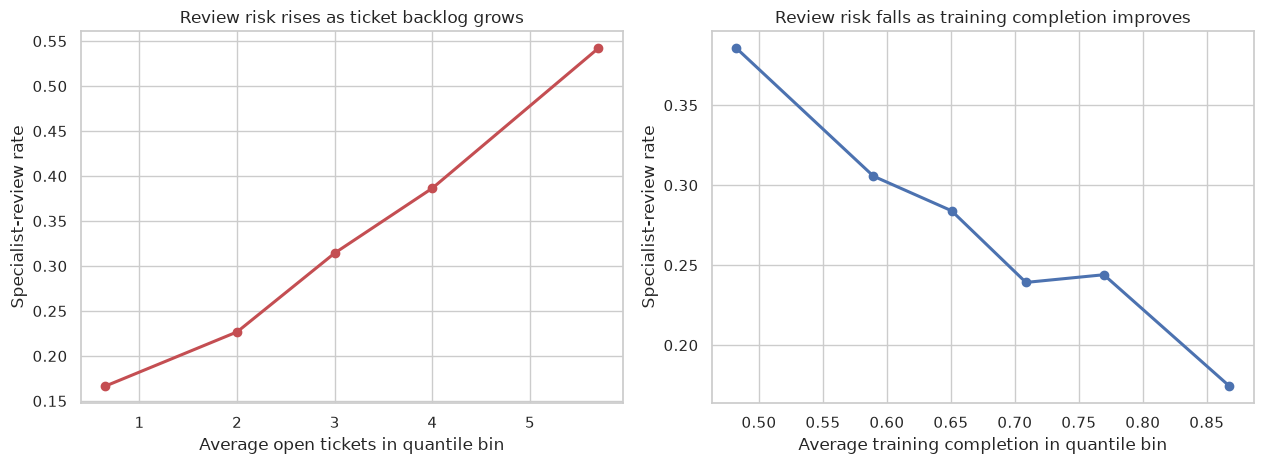

In [3]:
# Section focus: 2. Synthetic Case Study: Account Triage Under Service Risk.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

df = make_account_triage_dataset()
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=2026,
    stratify=df['needs_specialist_review'],
)

continuous_features = [
    'open_tickets_30d',
    'integration_complexity',
    'training_completion',
    'product_adoption',
    'payment_delay_days',
    'recent_incidents_90d',
    'usage_volatility',
]
binary_numeric_features = ['executive_sponsor']
numeric_features = binary_numeric_features + continuous_features
categorical_features = ['segment', 'region', 'support_motion']
all_features = numeric_features + categorical_features

overview = pd.DataFrame(
    [
        {'quantity': 'Rows', 'value': len(df)},
        {'quantity': 'Train rows', 'value': len(train_df)},
        {'quantity': 'Test rows', 'value': len(test_df)},
        {'quantity': 'Mean support hours', 'value': round(df['support_hours_next_30d'].mean(), 2)},
        {'quantity': 'Specialist-review rate', 'value': round(df['needs_specialist_review'].mean(), 3)},
        {'quantity': 'Average open tickets', 'value': round(df['open_tickets_30d'].mean(), 2)},
    ]
)
segment_summary = (
    df.groupby('segment', as_index=False)
    .agg(
        rows=('segment', 'size'),
        mean_support_hours=('support_hours_next_30d', 'mean'),
        review_rate=('needs_specialist_review', 'mean'),
    )
)

smart_display(overview)
smart_display(df.head(6))
smart_display(segment_summary.round(3))

ticket_curve = rate_by_quantile(df, 'open_tickets_30d', 'needs_specialist_review', q=6)
training_curve = rate_by_quantile(df, 'training_completion', 'needs_specialist_review', q=6)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

axes[0].plot(
    ticket_curve['mean_feature'],
    ticket_curve['target_rate'],
    marker='o',
    linewidth=2.2,
    color='#c44e52',
)
axes[0].set_title('Review risk rises as ticket backlog grows')
axes[0].set_xlabel('Average open tickets in quantile bin')
axes[0].set_ylabel('Specialist-review rate')

axes[1].plot(
    training_curve['mean_feature'],
    training_curve['target_rate'],
    marker='o',
    linewidth=2.2,
    color='#4c72b0',
)
axes[1].set_title('Review risk falls as training completion improves')
axes[1].set_xlabel('Average training completion in quantile bin')
axes[1].set_ylabel('Specialist-review rate')

plt.tight_layout()
plt.show()

The raw patterns already suggest why interpretation will matter.

- Higher backlog is associated with sharply higher specialist-review risk.
- Better training completion is associated with lower risk, but the relationship is not likely to be purely linear once backlog becomes extreme.
- Segment summaries show that enterprise accounts are structurally different rather than simply more of the same.

That is precisely why coefficient reading needs discipline. A single global coefficient table compresses these patterns, but it does not erase the heterogeneity underneath them.

## 3. Linear Coefficients: Raw Units Versus Comparable Effects

We begin with the continuous outcome `support_hours_next_30d`. A ridge model keeps the score transparent while stabilizing coefficients in the presence of correlated operational features:

$$
\hat y_i = \beta_0 + x_i^\top \beta,
$$

with shrinkage estimate

$$
\hat\beta_{\text{ridge}} = \arg\min_\beta \sum_{i=1}^n \bigl(y_i - \beta_0 - x_i^\top\beta\bigr)^2 + \lambda \lVert\beta\rVert_2^2.
$$

Even though the raw coefficients remain interpretable, their magnitudes cannot be compared naively when the predictors use different units. A coefficient measured per ticket, per day, or per unit interval of a proportion is answering a different question in each case.

A better comparison scale for numeric predictors is the effect of a one-standard-deviation shift:

$$
\Delta \hat y_{\text{1 SD},j} = \beta_j \cdot \operatorname{SD}(X_j).
$$

That does **not** replace the raw coefficient. It complements it.

,model,rmse,mae,r_squared
0,Raw-unit ridge,2.011,1.612,0.724


,feature,coefficient,feature_sd,one_sd_effect
0,training_completion,-3.998,0.129,-0.517
1,usage_volatility,1.537,0.621,0.955
2,product_adoption,-1.349,0.129,-0.174
3,recent_incidents_90d,1.311,1.037,1.359
4,open_tickets_30d,1.070,1.699,1.817
6,executive_sponsor,-0.842,0.489,-0.412
7,integration_complexity,0.601,1.431,0.860
11,payment_delay_days,0.089,3.070,0.275


,categorical_field,reference_level
0,segment,growth
1,region,North
2,support_motion,reactive


,feature,coefficient
5,segment = enterprise,0.924
9,region = International,0.270
10,region = West,0.159
12,region = South,0.082
14,segment = mid-market,-0.015


,feature,shift,predicted_change_in_hours
0,open_tickets_30d,+3 tickets,3.209
5,recent_incidents_90d,+1 incident,1.311
1,integration_complexity,+2 complexity points,1.202
7,executive_sponsor,0 -> 1,-0.842
6,usage_volatility,+0.5 volatility units,0.769
4,payment_delay_days,+5 days,0.447
2,training_completion,-10 percentage points,0.400
3,product_adoption,-10 percentage points,0.135


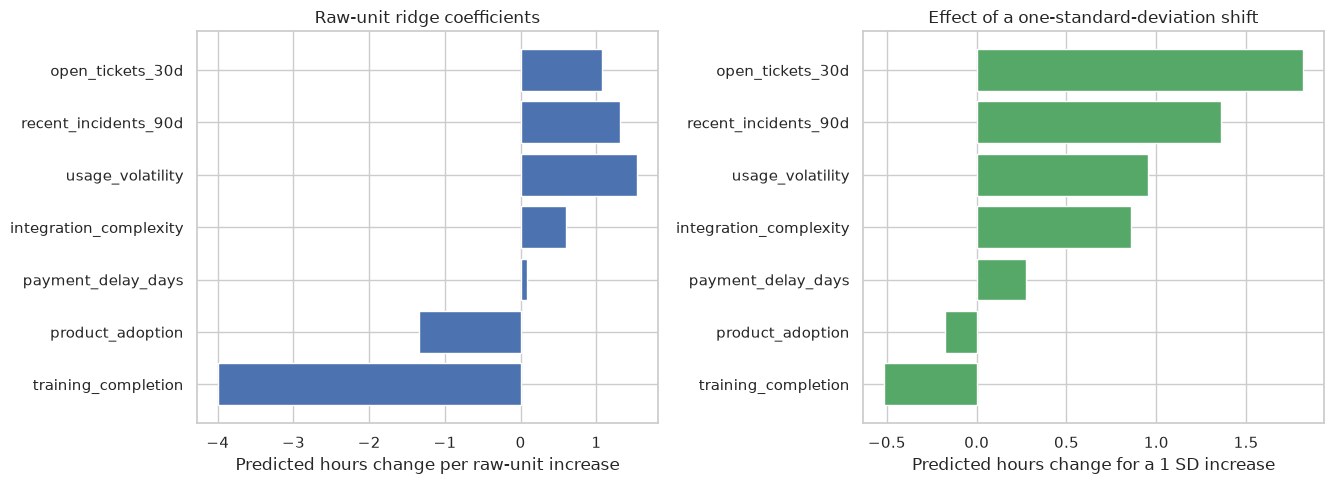

In [4]:
# Section focus: 3. Linear Coefficients: Raw Units Versus Comparable Effects.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

linear_preprocessor = build_preprocessor(numeric_features, categorical_features)
linear_model = Pipeline(
    steps=[
        ('preprocessor', linear_preprocessor),
        ('model', Ridge(alpha=1.0)),
    ]
)
linear_model.fit(train_df[all_features], train_df['support_hours_next_30d'])

support_pred = linear_model.predict(test_df[all_features])
linear_metrics = pd.DataFrame([{'model': 'Raw-unit ridge', **regression_metrics(test_df['support_hours_next_30d'], support_pred)}])
smart_display(linear_metrics.round(3))

linear_coef = coefficient_table_from_pipeline(linear_model)
feature_sd = train_df[numeric_features].std()
linear_coef['feature_sd'] = linear_coef['feature'].map(feature_sd)
linear_coef['one_sd_effect'] = linear_coef['coefficient'] * linear_coef['feature_sd']

linear_numeric = linear_coef[linear_coef['feature'].isin(continuous_features + binary_numeric_features)].copy()
linear_categories = linear_coef[linear_coef['feature'].str.contains(' = ')].copy()

linear_shift_rows = []
for feature, (shift_label, delta) in MEANINGFUL_SHIFTS.items():
    beta = linear_numeric.loc[linear_numeric['feature'] == feature, 'coefficient'].iloc[0]
    linear_shift_rows.append(
        {
            'feature': feature,
            'shift': shift_label,
            'predicted_change_in_hours': beta * delta,
        }
    )
linear_shift_table = pd.DataFrame(linear_shift_rows).sort_values('predicted_change_in_hours', key=np.abs, ascending=False)

reference_levels = pd.DataFrame(
    {
        'categorical_field': list(CATEGORICAL_LEVELS.keys()),
        'reference_level': [levels[0] for levels in CATEGORICAL_LEVELS.values()],
    }
)

smart_display(linear_numeric[['feature', 'coefficient', 'feature_sd', 'one_sd_effect']].round(3))
smart_display(reference_levels)
smart_display(linear_categories[['feature', 'coefficient']].head(8).round(3))
smart_display(linear_shift_table.round(3))

plot_linear = linear_numeric[linear_numeric['feature'].isin(continuous_features)].copy()
plot_linear = plot_linear.sort_values('one_sd_effect')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

axes[0].barh(plot_linear['feature'], plot_linear['coefficient'], color='#4c72b0')
axes[0].set_title('Raw-unit ridge coefficients')
axes[0].set_xlabel('Predicted hours change per raw-unit increase')
axes[0].set_ylabel('')

axes[1].barh(plot_linear['feature'], plot_linear['one_sd_effect'], color='#55a868')
axes[1].set_title('Effect of a one-standard-deviation shift')
axes[1].set_xlabel('Predicted hours change for a 1 SD increase')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

This result sits between model performance and the operating policy. The useful reading is which metric would change the action in Linear Coefficients: Raw Units Versus Comparable Effects. The right rule depends on the cost, capacity, or governance constraint that matters most.


### Discussion of the Linear Model

The ridge model is already useful operationally, but the most important lesson here is interpretive.

- The raw coefficients answer questions in the feature's native units. For `open_tickets_30d`, the slope is the added support burden per extra open ticket. For `payment_delay_days`, it is the added burden per day of delay.
- Those raw coefficients are **not** comparable across features because the unit steps are different.
- The one-standard-deviation effect puts numeric features onto a shared comparison scale and reveals which variables move the prediction most over their observed range.

This is why Gelman (2007) argued that regression interpretation is highly sensitive to scaling. In decision work, the clean habit is: use raw coefficients to speak in business units, and use standardized effects to compare numeric drivers.

## 4. Logistic Coefficients: Log-Odds, Odds Ratios, and Probability Changes

For the binary target `needs_specialist_review`, we fit a logistic model on the same raw features:

$$
\log\!\left(\frac{p(x)}{1-p(x)}\right) = \beta_0 + x^\top \beta.
$$

A coefficient is easiest to translate through an odds ratio. If a feature changes by $\Delta$, then

$$
\operatorname{OR}(\Delta) = e^{\beta \Delta}.
$$

But probability translation is more subtle because

$$
\frac{\partial p(x)}{\partial x_j} = p(x)(1-p(x))\beta_j.
$$

So the same odds multiplier can correspond to a tiny absolute risk increase near $p=0.01$, a large increase around $p=0.50$, and again a small increase near $p=0.99$.

,model,roc_auc,average_precision,brier_score,log_loss,mean_predicted_risk
0,Raw-unit logistic,0.812,0.648,0.146,0.452,0.264


,feature,coefficient,unit_odds_ratio,one_sd_odds_ratio
0,training_completion,-2.804,0.061,0.696
1,product_adoption,-1.557,0.211,0.818
2,executive_sponsor,-0.952,0.386,0.628
3,usage_volatility,0.830,2.292,1.674
4,recent_incidents_90d,0.580,1.785,1.824
7,open_tickets_30d,0.278,1.320,1.603
8,integration_complexity,0.253,1.288,1.436
11,payment_delay_days,0.057,1.058,1.191


,feature,coefficient,unit_odds_ratio
5,segment = enterprise,0.544,1.724
6,region = International,0.279,1.322
10,region = South,0.085,1.089
13,segment = mid-market,0.045,1.046
14,region = West,0.013,1.013


,feature,shift,log_odds_change,odds_multiplier
7,executive_sponsor,0 -> 1,-0.952,0.386
0,open_tickets_30d,+3 tickets,0.834,2.302
5,recent_incidents_90d,+1 incident,0.580,1.785
1,integration_complexity,+2 complexity points,0.506,1.658
6,usage_volatility,+0.5 volatility units,0.415,1.514
4,payment_delay_days,+5 days,0.284,1.328
2,training_completion,-10 percentage points,0.280,1.324
3,product_adoption,-10 percentage points,0.156,1.168


,profile,baseline_probability,probability_after_+3_tickets,absolute_probability_change
0,Low-risk account,0.009,0.020,0.011
1,Mid-risk account,0.295,0.491,0.196
2,High-risk account,0.971,0.987,0.016


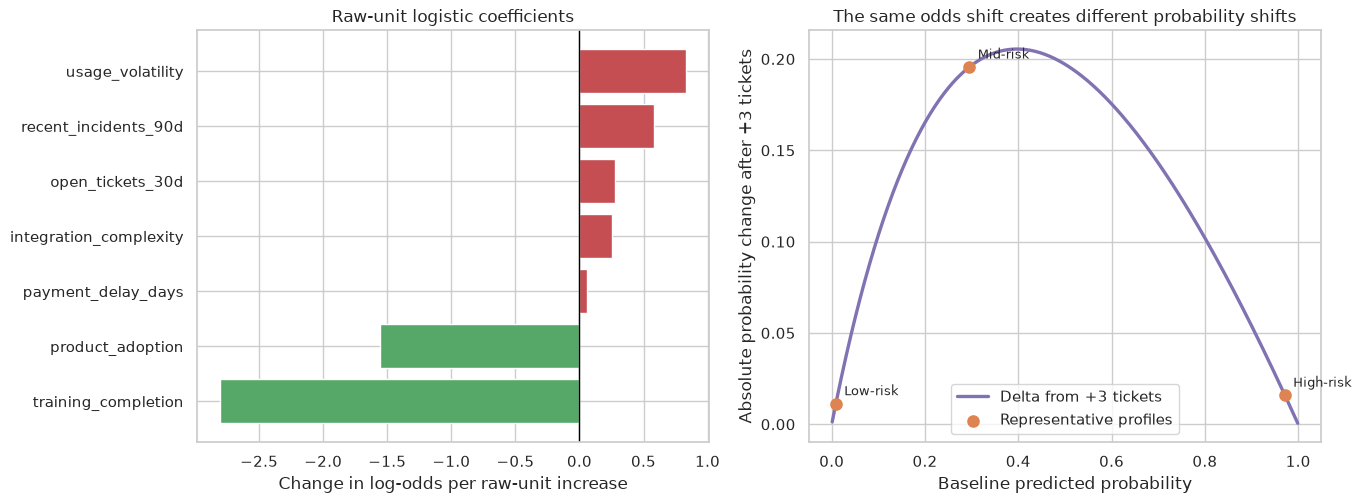

In [5]:
# Section focus: 4. Logistic Coefficients: Log-Odds, Odds Ratios, and Probability Changes.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

logit_preprocessor = build_preprocessor(numeric_features, categorical_features)
logit_model = Pipeline(
    steps=[
        ('preprocessor', logit_preprocessor),
        ('model', LogisticRegression(max_iter=5000, C=10.0)),
    ]
)
logit_model.fit(train_df[all_features], train_df['needs_specialist_review'])

review_prob = logit_model.predict_proba(test_df[all_features])[:, 1]
logit_metrics = pd.DataFrame([{'model': 'Raw-unit logistic', **classification_metrics(test_df['needs_specialist_review'], review_prob)}])
smart_display(logit_metrics.round(3))

logit_coef = coefficient_table_from_pipeline(logit_model)
logit_coef['feature_sd'] = logit_coef['feature'].map(feature_sd)
logit_coef['one_sd_log_odds_shift'] = logit_coef['coefficient'] * logit_coef['feature_sd']
logit_coef['one_sd_odds_ratio'] = np.exp(logit_coef['one_sd_log_odds_shift'])
logit_coef['unit_odds_ratio'] = np.exp(logit_coef['coefficient'])

logit_numeric = logit_coef[logit_coef['feature'].isin(continuous_features + binary_numeric_features)].copy()
logit_categories = logit_coef[logit_coef['feature'].str.contains(' = ')].copy()

logit_shift_rows = []
for feature, (shift_label, delta) in MEANINGFUL_SHIFTS.items():
    beta = logit_numeric.loc[logit_numeric['feature'] == feature, 'coefficient'].iloc[0]
    logit_shift_rows.append(
        {
            'feature': feature,
            'shift': shift_label,
            'log_odds_change': beta * delta,
            'odds_multiplier': np.exp(beta * delta),
        }
    )
logit_shift_table = pd.DataFrame(logit_shift_rows).sort_values('odds_multiplier', key=lambda s: np.abs(np.log(s)), ascending=False)

smart_display(logit_numeric[['feature', 'coefficient', 'unit_odds_ratio', 'one_sd_odds_ratio']].round(3))
smart_display(logit_categories[['feature', 'coefficient', 'unit_odds_ratio']].head(8).round(3))
smart_display(logit_shift_table.round(3))

representative_profiles = pd.DataFrame(
    [
        {
            'profile': 'Low-risk account',
            'executive_sponsor': 1,
            'open_tickets_30d': 1,
            'integration_complexity': 4.0,
            'training_completion': 0.88,
            'product_adoption': 0.75,
            'payment_delay_days': 1.0,
            'recent_incidents_90d': 0,
            'usage_volatility': 0.35,
            'segment': 'growth',
            'region': 'North',
            'support_motion': 'reactive',
        },
        {
            'profile': 'Mid-risk account',
            'executive_sponsor': 0,
            'open_tickets_30d': 3,
            'integration_complexity': 5.6,
            'training_completion': 0.70,
            'product_adoption': 0.60,
            'payment_delay_days': 4.0,
            'recent_incidents_90d': 1,
            'usage_volatility': 0.75,
            'segment': 'mid-market',
            'region': 'West',
            'support_motion': 'pooled',
        },
        {
            'profile': 'High-risk account',
            'executive_sponsor': 0,
            'open_tickets_30d': 6,
            'integration_complexity': 7.0,
            'training_completion': 0.52,
            'product_adoption': 0.45,
            'payment_delay_days': 7.0,
            'recent_incidents_90d': 3,
            'usage_volatility': 1.20,
            'segment': 'enterprise',
            'region': 'International',
            'support_motion': 'pooled',
        },
    ]
)

profile_base_prob = logit_model.predict_proba(representative_profiles[all_features])[:, 1]
profile_plus_tickets = representative_profiles.copy()
profile_plus_tickets['open_tickets_30d'] = profile_plus_tickets['open_tickets_30d'] + 3
profile_plus_prob = logit_model.predict_proba(profile_plus_tickets[all_features])[:, 1]

profile_shift_table = pd.DataFrame(
    {
        'profile': representative_profiles['profile'],
        'baseline_probability': profile_base_prob,
        'probability_after_+3_tickets': profile_plus_prob,
        'absolute_probability_change': profile_plus_prob - profile_base_prob,
    }
)
smart_display(profile_shift_table.round(3))

beta_tickets = logit_numeric.loc[logit_numeric['feature'] == 'open_tickets_30d', 'coefficient'].iloc[0]
base_prob_grid = np.linspace(0.001, 0.999, 400)
base_logit_grid = np.log(base_prob_grid / (1 - base_prob_grid))
shifted_prob_grid = sigmoid(base_logit_grid + 3 * beta_tickets)
delta_prob_grid = shifted_prob_grid - base_prob_grid

plot_logit = logit_numeric[logit_numeric['feature'].isin(continuous_features)].copy().sort_values('coefficient')
colors = np.where(plot_logit['coefficient'] > 0, '#c44e52', '#55a868')

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2))

axes[0].barh(plot_logit['feature'], plot_logit['coefficient'], color=colors)
axes[0].set_title('Raw-unit logistic coefficients')
axes[0].set_xlabel('Change in log-odds per raw-unit increase')
axes[0].set_ylabel('')
axes[0].axvline(0.0, color='black', linewidth=1.0)

axes[1].plot(base_prob_grid, delta_prob_grid, color='#8172b2', linewidth=2.4, label='Delta from +3 tickets')
axes[1].scatter(
    profile_shift_table['baseline_probability'],
    profile_shift_table['absolute_probability_change'],
    color='#dd8452',
    s=65,
    zorder=3,
    label='Representative profiles',
)
for _, row in profile_shift_table.iterrows():
    axes[1].annotate(
        row['profile'].replace(' account', ''),
        (row['baseline_probability'], row['absolute_probability_change']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9,
    )
axes[1].set_title('The same odds shift creates different probability shifts')
axes[1].set_xlabel('Baseline predicted probability')
axes[1].set_ylabel('Absolute probability change after +3 tickets')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

This output matters because the result has to support an operating decision. For Logistic Coefficients: Log-Odds, Odds Ratios, and Probability Changes, the result should tell us which cases are actionable, which are ambiguous, and where human review is needed. The implication is an operating policy with an investigation path.


### Discussion of the Logistic Model

Three interpretation lessons stand out.

1. **Reference levels matter.** A coefficient such as `segment = enterprise` is always interpreted relative to the dropped baseline `segment = growth`, conditional on the rest of the modeled features.
2. **Odds changes are not probability changes.** In the profile table, the same `+3 tickets` move multiplies the odds by the same factor for every account, but the absolute probability jump is largest for the middle-risk account because that case sits in the steep part of the sigmoid curve.
3. **Meaningful shifts beat generic one-unit shifts.** A one-day increase in `payment_delay_days` and a one-ticket increase in `open_tickets_30d` are not equally natural business moves. The shift table translates the model into changes that stakeholders actually reason about.

LaValley (2008) and Sperandei (2014) both emphasize that odds ratios are the natural language of logistic regression, but they are easy to overread if analysts silently treat them as probability ratios or risk differences.

## 5. Response Surfaces for Interactions and Nonlinear Structure

Coefficient tables become even harder to read once we explicitly engineer interactions and nonlinear terms. Suppose we enrich the logistic score with a few transparent features:

- `training_gap = 1 - training_completion`
- `ticket_x_training_gap = open_tickets_30d \times training_gap`
- `training_x_adoption_gap = training_gap \times (1 - product_adoption)`
- `ticket_tail = \max(open_tickets_30d - 5, 0)`
- `adoption_gap_sq = (1 - product_adoption)^2`

To keep the parametrization identifiable and interpretable, the enriched model uses the gap-style variables `training_gap` and `adoption_gap` **instead of** including both those gaps and their raw complements in the same design matrix.

The model is still transparent because every term is explicit, but interpretation should now move from isolated coefficients to **surfaces**.

If a logistic predictor contains

$$
\eta(x) = \beta_0 + \beta_1 T + \beta_2 G + \beta_3 TG,
$$

then the effect of more tickets on the log-odds scale is

$$
\frac{\partial \eta}{\partial T} = \beta_1 + \beta_3 G,
$$

which already depends on the level of the other variable. On the probability scale it becomes

$$
\frac{\partial p}{\partial T} = p(x)\bigl(1-p(x)\bigr)\bigl(\beta_1 + \beta_3 G\bigr),
$$

so both the interaction term and the current risk level matter. This is the logic behind Ai and Norton (2003): in nonlinear models, the interaction coefficient by itself is not the whole story.

,model,roc_auc,average_precision,brier_score,log_loss,mean_predicted_risk
0,Raw-unit logistic,0.812000,0.648000,0.146000,0.452000,0.264000
1,Logistic with explicit interactions,0.812000,0.651000,0.145000,0.451000,0.264000


,feature,coefficient
0,training_x_adoption_gap,2.114
1,adoption_gap,1.846
2,adoption_gap_sq,-1.068
4,training_gap,0.896
8,ticket_x_training_gap,0.377
11,ticket_tail,0.223
13,open_tickets_30d,0.124


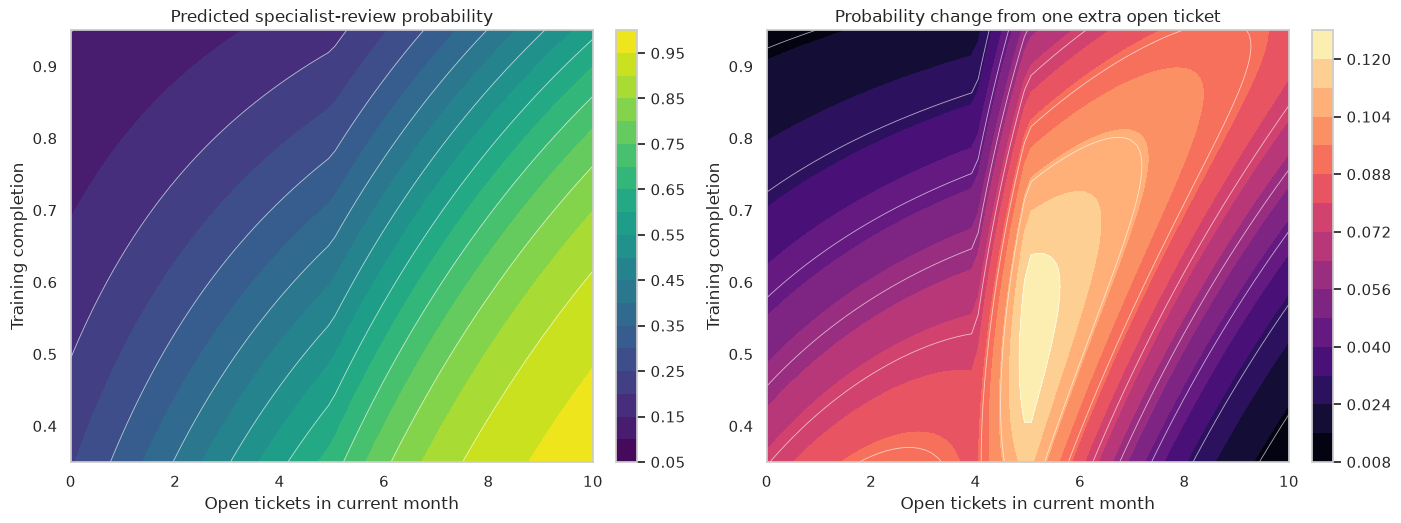

In [6]:
# Section focus: 5. Response Surfaces for Interactions and Nonlinear Structure.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

train_enriched = add_engineered_features(train_df)
test_enriched = add_engineered_features(test_df)

enriched_numeric_features = [
    'executive_sponsor',
    'open_tickets_30d',
    'integration_complexity',
    'payment_delay_days',
    'recent_incidents_90d',
    'usage_volatility',
    'training_gap',
    'adoption_gap',
    'ticket_x_training_gap',
    'training_x_adoption_gap',
    'ticket_tail',
    'adoption_gap_sq',
]

enriched_preprocessor = build_preprocessor(enriched_numeric_features, categorical_features)
enriched_logit_model = Pipeline(
    steps=[
        ('preprocessor', enriched_preprocessor),
        ('model', LogisticRegression(max_iter=5000, C=10.0)),
    ]
)
enriched_logit_model.fit(train_enriched[enriched_numeric_features + categorical_features], train_enriched['needs_specialist_review'])

enriched_prob = enriched_logit_model.predict_proba(test_enriched[enriched_numeric_features + categorical_features])[:, 1]
comparison_table = pd.DataFrame(
    [
        {'model': 'Raw-unit logistic', **classification_metrics(test_df['needs_specialist_review'], review_prob)},
        {'model': 'Logistic with explicit interactions', **classification_metrics(test_enriched['needs_specialist_review'], enriched_prob)},
    ]
)
smart_display(comparison_table.round(3))

enriched_coef = coefficient_table_from_pipeline(enriched_logit_model)
key_terms = enriched_coef[enriched_coef['feature'].isin(['open_tickets_30d', 'training_gap', 'adoption_gap', 'ticket_x_training_gap', 'training_x_adoption_gap', 'ticket_tail', 'adoption_gap_sq'])].copy()
smart_display(key_terms[['feature', 'coefficient']].round(3))

surface_tickets = np.linspace(0, 10, 80)
surface_training = np.linspace(0.35, 0.95, 80)
T, G = np.meshgrid(surface_tickets, surface_training)
base_profile = pd.DataFrame(
    {
        'executive_sponsor': np.zeros(T.size),
        'open_tickets_30d': T.ravel(),
        'integration_complexity': np.repeat(train_df['integration_complexity'].median(), T.size),
        'training_completion': G.ravel(),
        'product_adoption': np.repeat(train_df['product_adoption'].median(), T.size),
        'payment_delay_days': np.repeat(train_df['payment_delay_days'].median(), T.size),
        'recent_incidents_90d': np.repeat(train_df['recent_incidents_90d'].median(), T.size),
        'usage_volatility': np.repeat(train_df['usage_volatility'].median(), T.size),
        'segment': np.repeat('mid-market', T.size),
        'region': np.repeat('North', T.size),
        'support_motion': np.repeat('pooled', T.size),
    }
)
base_profile = add_engineered_features(base_profile)
base_surface = enriched_logit_model.predict_proba(base_profile[enriched_numeric_features + categorical_features])[:, 1].reshape(T.shape)

plus_one_ticket = base_profile.copy()
plus_one_ticket['open_tickets_30d'] = plus_one_ticket['open_tickets_30d'] + 1
plus_one_ticket = add_engineered_features(plus_one_ticket[all_features])
plus_one_surface = enriched_logit_model.predict_proba(plus_one_ticket[enriched_numeric_features + categorical_features])[:, 1].reshape(T.shape)
delta_surface = plus_one_surface - base_surface

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.4))

im0 = axes[0].contourf(T, G, base_surface, levels=18, cmap='viridis')
axes[0].contour(T, G, base_surface, levels=8, colors='white', linewidths=0.6, alpha=0.65)
axes[0].set_title('Predicted specialist-review probability')
axes[0].set_xlabel('Open tickets in current month')
axes[0].set_ylabel('Training completion')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].contourf(T, G, delta_surface, levels=18, cmap='magma')
axes[1].contour(T, G, delta_surface, levels=8, colors='white', linewidths=0.6, alpha=0.65)
axes[1].set_title('Probability change from one extra open ticket')
axes[1].set_xlabel('Open tickets in current month')
axes[1].set_ylabel('Training completion')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Use the explanation as a stress test of the model narrative. In Response Surfaces for Interactions and Nonlinear Structure, the displayed reasons should make sense with the data-generating story and the operating decision. Disagreement across explanation views changes how confidently the result can be communicated.


### Discussion of the Response Surfaces

The enriched model remains transparent, but the heatmaps make clear why coefficient tables are no longer enough.

- The left panel shows the overall risk surface. Risk increases as ticket pressure grows and training completion weakens, but the surface is not a flat plane.
- The right panel shows the marginal probability effect of **one more open ticket**. That effect is strongest in the middle band where the account is already vulnerable but not yet saturated at near-certain risk.
- A positive interaction term such as `ticket_x_training_gap` helps tell this story, but it does not tell the whole story by itself. The full probability effect depends on where the account sits on the surface.

This is the main interpretability payoff of response surfaces: they preserve transparency while restoring the geometry that a coefficient table has compressed away.

## 6. A Checklist for Not Misreading Transparent Models

| Tempting shortcut | Why it is wrong | Better habit |
|---|---|---|
| Compare raw coefficient magnitudes across differently scaled numeric features | Units differ, so the coefficients answer different one-unit questions | Compare meaningful business shifts or one-standard-deviation effects |
| Read an odds ratio as a probability multiplier | Odds and probabilities are different objects | Translate odds ratios into profile-specific probability changes |
| Treat a category coefficient as absolute rather than baseline-relative | One-hot coding always drops a reference level | State the omitted reference explicitly |
| Treat an interaction coefficient as the full interaction effect in logistic models | Probability effects vary with the rest of the covariates and baseline risk | Use response surfaces or marginal-effect plots |
| Equate a predictive coefficient with a causal effect | Predictive association does not identify intervention effect | Keep interpretation explicitly predictive unless a causal design justifies more |
| Assume a transparent model never needs visualization | Coefficients hide curvature and saturation | Plot surfaces, slices, and representative profiles |

In [7]:
# Section focus: 6. A Checklist for Not Misreading Transparent Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

example_accounts = pd.DataFrame(
    [
        {
            'account': 'A: healthy growth account',
            'executive_sponsor': 1,
            'open_tickets_30d': 1,
            'integration_complexity': 3.8,
            'training_completion': 0.90,
            'product_adoption': 0.78,
            'payment_delay_days': 1.0,
            'recent_incidents_90d': 0,
            'usage_volatility': 0.30,
            'segment': 'growth',
            'region': 'North',
            'support_motion': 'reactive',
        },
        {
            'account': 'B: stretched mid-market account',
            'executive_sponsor': 0,
            'open_tickets_30d': 4,
            'integration_complexity': 5.8,
            'training_completion': 0.66,
            'product_adoption': 0.58,
            'payment_delay_days': 5.0,
            'recent_incidents_90d': 1,
            'usage_volatility': 0.82,
            'segment': 'mid-market',
            'region': 'West',
            'support_motion': 'pooled',
        },
        {
            'account': 'C: fragile enterprise account',
            'executive_sponsor': 0,
            'open_tickets_30d': 7,
            'integration_complexity': 7.2,
            'training_completion': 0.50,
            'product_adoption': 0.44,
            'payment_delay_days': 8.0,
            'recent_incidents_90d': 3,
            'usage_volatility': 1.25,
            'segment': 'enterprise',
            'region': 'International',
            'support_motion': 'pooled',
        },
    ]
)
example_enriched = add_engineered_features(example_accounts)

example_summary = example_accounts[['account']].copy()
example_summary['predicted_support_hours'] = linear_model.predict(example_accounts[all_features])
example_summary['baseline_review_probability'] = logit_model.predict_proba(example_accounts[all_features])[:, 1]
example_summary['interaction_aware_review_probability'] = enriched_logit_model.predict_proba(example_enriched[enriched_numeric_features + categorical_features])[:, 1]
smart_display(example_summary.round(3))

,account,predicted_support_hours,baseline_review_probability,interaction_aware_review_probability
0,A: healthy growth account,6.970000,0.007000,0.009000
1,B: stretched mid-market account,16.518000,0.430000,0.421000
2,C: fragile enterprise account,26.000000,0.982000,0.990000


This result is an interpretation diagnostic. For A Checklist for Not Misreading Transparent Models, look at whether the explanation is stable, plausible, and useful for stakeholder review. A fragile narrative has value when the report is explicit about where it shifts.


## 7. Takeaways

A transparent model does not become informative just because we can print its coefficients. Interpretation still requires good habits.

- Raw coefficients live in raw units and should be translated into meaningful operational shifts.
- Standardized effects help compare numeric predictors, but they are not a replacement for business-unit interpretation.
- Logistic coefficients are constant on the log-odds scale, not on the probability scale.
- Once interactions or nonlinear terms enter the model, response surfaces are often the clearest honest summary.
- Transparency helps governance, but only if analysts refuse to oversimplify what the model is actually saying.

The next notebook extends this logic from interpretation to **shape constraints and monotonicity**, where we will ask how to encode domain logic directly into the model class rather than only explaining the fitted result afterward.

## References

- Gelman, A. (2007). *Scaling regression inputs by dividing by two standard deviations*. *Statistics in Medicine, 27*(15), 2865-2873. [https://doi.org/10.1002/sim.3107](https://doi.org/10.1002/sim.3107)
- Sperandei, S. (2014). *Understanding logistic regression analysis*. *Biochemia Medica, 24*, 12-18. [https://doi.org/10.11613/BM.2014.003](https://doi.org/10.11613/BM.2014.003)
- LaValley, M. P. (2008). *Logistic regression*. *Circulation, 117*(18), 2395-2399. [https://doi.org/10.1161/CIRCULATIONAHA.106.682658](https://doi.org/10.1161/CIRCULATIONAHA.106.682658)
- Ai, C., & Norton, E. C. (2003). *Interaction terms in logit and probit models*. *Economics Letters, 80*(1), 123-129. [https://doi.org/10.1016/S0165-1765(03)00032-6](https://doi.org/10.1016/S0165-1765%2803%2900032-6)
- Norton, E. C., Dowd, B., & Maciejewski, M. L. (2019). *Marginal Effects-Quantifying the Effect of Changes in Risk Factors in Logistic Regression Models*. *JAMA, 321*(13), 1304. [https://doi.org/10.1001/jama.2019.1954](https://doi.org/10.1001/jama.2019.1954)
